# Train log 曲線

在下一個儲存格設定 `TRAIN_LOG_PATH`，再執行其後的繪圖儲存格。圖表會在 Notebook 內顯示，並另存為與 `train.log` 同目錄下的 `train_curves.png`。若 log 內含驗證 SSIM（與 PSNR 同一行），會額外繪製 SSIM 曲線；否則略過。

In [3]:
from pathlib import Path

# 在此指定 train.log 路徑（字串或 Path 皆可）
TRAIN_LOG_PATH = Path("/mnt/newdisk/Documents/linzhanyang/DehazeDDPM/experiments/Dehaze_ColdFog_finetune_netH_physical_v1_260508_123402/logs/train.log")

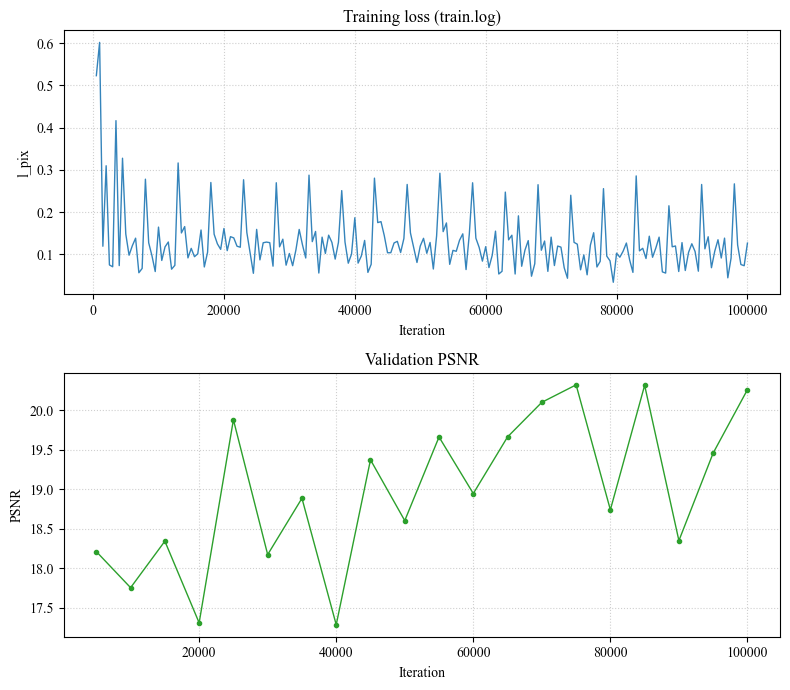

Saved: /mnt/newdisk/Documents/linzhanyang/DehazeDDPM/experiments/Dehaze_ColdFog_finetune_netH_physical_v1_260508_123402/logs/train_curves.png
Parsed 200 l_pix points, 20 validation PSNR points. (no SSIM in log, skipped).


In [4]:
%matplotlib inline
from __future__ import annotations

import re

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "DejaVu Serif", "Times", "Nimbus Roman"]
plt.rcParams["axes.unicode_minus"] = False

_LINE_L_PIX = re.compile(
    r"<epoch:\s*(\d+),\s*iter:\s*([\d,\s]+)>\s+l_pix:\s*([\deE.+-]+)"
)
_LINE_VAL = re.compile(
    r"<epoch:\s*(\d+),\s*iter:\s*([\d,\s]+)>\s+psnr:\s*([\deE.+-]+)"
    r"(?:,\s*ssim[：:]\s*([\deE.+-]+))?"
)


def _parse_iter(s: str) -> int:
    return int(re.sub(r"[\s,]", "", s))


def parse_train_log(
    path: Path,
) -> tuple[list[int], list[float], list[int], list[float], list[int], list[float]]:
    text = path.read_text(encoding="utf-8", errors="replace")
    iters_l: list[int] = []
    l_pix: list[float] = []
    iters_v: list[int] = []
    psnr: list[float] = []
    iters_ssim: list[int] = []
    ssim: list[float] = []
    for line in text.splitlines():
        m = _LINE_L_PIX.search(line)
        if m:
            iters_l.append(_parse_iter(m.group(2)))
            l_pix.append(float(m.group(3)))
            continue
        m = _LINE_VAL.search(line)
        if m:
            it = _parse_iter(m.group(2))
            iters_v.append(it)
            psnr.append(float(m.group(3)))
            if m.group(4) is not None:
                iters_ssim.append(it)
                ssim.append(float(m.group(4)))
    return iters_l, l_pix, iters_v, psnr, iters_ssim, ssim


def plot_curves_notebook(
    log_path: Path,
    iters_l: list[int],
    l_pix: list[float],
    iters_v: list[int],
    psnr: list[float],
    iters_ssim: list[int],
    ssim: list[float],
) -> Path:
    n_plots = 0
    if iters_l:
        n_plots += 1
    if iters_v:
        n_plots += 1
    if iters_ssim:
        n_plots += 1
    if n_plots == 0:
        raise ValueError(f"No plottable metrics found in {log_path}")

    fig, axes = plt.subplots(n_plots, 1, figsize=(8, 3.5 * n_plots), squeeze=False)
    ax_list = axes.flatten().tolist()
    i_ax = 0

    if iters_l:
        ax = ax_list[i_ax]
        i_ax += 1
        ax.plot(iters_l, l_pix, color="#1f77b4", linewidth=1.0, alpha=0.9)
        ax.set_xlabel("Iteration")
        ax.set_ylabel("l_pix")
        ax.set_title(f"Training loss ({log_path.name})")
        ax.grid(True, linestyle=":", alpha=0.6)

    if iters_v:
        ax = ax_list[i_ax]
        i_ax += 1
        ax.plot(iters_v, psnr, color="#2ca02c", marker="o", markersize=3, linewidth=1.0)
        ax.set_xlabel("Iteration")
        ax.set_ylabel("PSNR")
        ax.set_title("Validation PSNR")
        ax.grid(True, linestyle=":", alpha=0.6)

    if iters_ssim:
        ax = ax_list[i_ax]
        ax.plot(iters_ssim, ssim, color="#ff7f0e", marker="o", markersize=3, linewidth=1.0)
        ax.set_xlabel("Iteration")
        ax.set_ylabel("SSIM")
        ax.set_title("Validation SSIM")
        ax.grid(True, linestyle=":", alpha=0.6)

    fig.tight_layout()
    out_path = log_path.parent / f"{log_path.stem}_curves.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    return out_path


log_path = TRAIN_LOG_PATH.expanduser().resolve()
if not log_path.is_file():
    raise FileNotFoundError(f"File not found: {log_path}")

iters_l, l_pix, iters_v, psnr, iters_ssim, ssim = parse_train_log(log_path)
out_png = plot_curves_notebook(
    log_path, iters_l, l_pix, iters_v, psnr, iters_ssim, ssim
)
print(f"Saved: {out_png}")
msg = f"Parsed {len(iters_l)} l_pix points, {len(iters_v)} validation PSNR points."
if iters_ssim:
    msg += f" {len(iters_ssim)} validation SSIM points."
else:
    msg += " (no SSIM in log, skipped)."
print(msg)